In [32]:
import pandas as pd

In [33]:
df = pd.read_csv("../dataset/loan_prediction.csv")

print(df.head())
print(df.info())
print(df.describe())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [34]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [35]:
df["LoanAmount"] = df["LoanAmount"].fillna(
    df["LoanAmount"].median()
)

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(
    df["Loan_Amount_Term"].median()
)

In [36]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\User\AppData\Local\Temp\ipykernel_35172\152405143.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [38]:
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

df["LoanIncomeRatio"] = (
    df["LoanAmount"] /
    df["TotalIncome"]
)

In [39]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [45]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7723577235772358


In [46]:
print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.7560975609756098


In [47]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Decision Tree Precision:", precision_score(y_test, dt_pred))
print("Decision Tree Recall:", recall_score(y_test, dt_pred))
print("Decision Tree F1 Score:", f1_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7723577235772358
Decision Tree Precision: 0.76
Decision Tree Recall: 0.95
Decision Tree F1 Score: 0.8444444444444444


In [48]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("KNN Precision:", precision_score(y_test, knn_pred))
print("KNN Recall:", recall_score(y_test, knn_pred))
print("KNN F1 Score:", f1_score(y_test, knn_pred))

KNN Accuracy: 0.7560975609756098
KNN Precision: 0.75
KNN Recall: 0.9375
KNN F1 Score: 0.8333333333333334


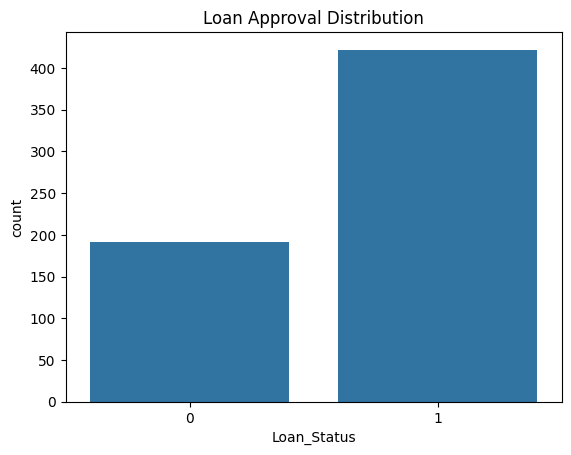

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")
plt.show()

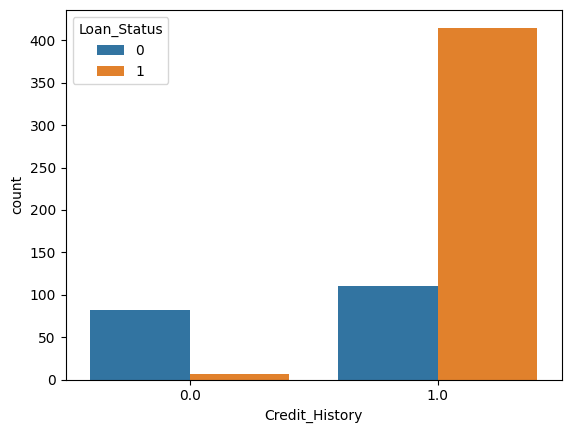

In [50]:
sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df
)

plt.show()

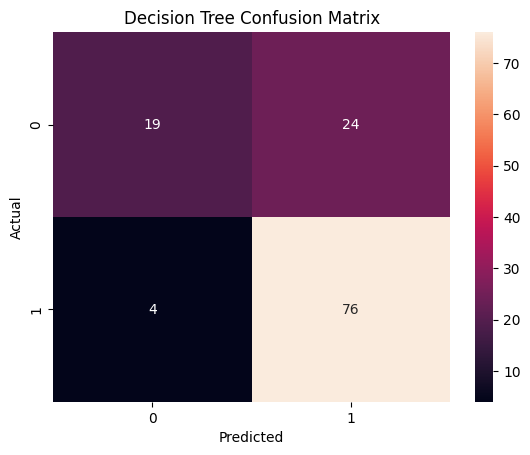

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt, annot=True, fmt='d')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

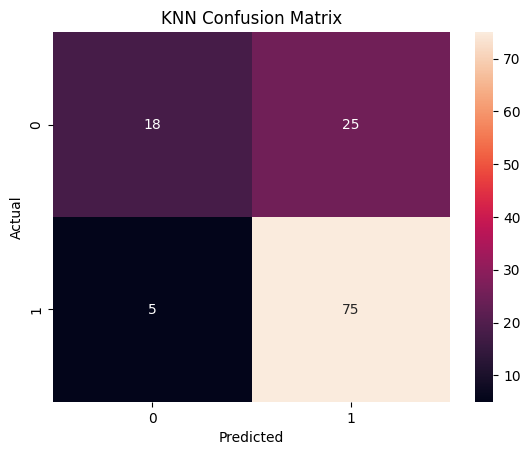

In [52]:
cm_knn = confusion_matrix(y_test, knn_pred)

sns.heatmap(cm_knn, annot=True, fmt='d')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()